In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import matplotlib

In [2]:
df = pd.read_csv('nr_ic_merged.csv')

In [3]:
# Keep only valid SMILES
def smiles_to_mol(s):
    if pd.isna(s) or str(s).lower() == 'nan':
        return None
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None


df['mol'] = df['Smiles'].map(smiles_to_mol)
df = df[df['mol'].notna()].copy()

In [4]:
FPSIZE = 4096
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FPSIZE)

def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((FPSIZE,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

df['fp'] = df['mol'].map(mol_to_fp)

In [5]:
encoder = OneHotEncoder(sparse_output=False)
target_encoded = encoder.fit_transform(df[['Target']])
target_names = encoder.categories_[0]

df['target_encoded'] = target_encoded.tolist()

In [6]:
df['fp_tuple'] = df['fp'].apply(lambda x: tuple(x))

# Group by fingerprint and OR-combine their one-hot target vectors
grouped = df.groupby('fp_tuple')['target_encoded'].apply(
    lambda rows: np.any(np.vstack(rows.values), axis=0).astype(int)
)

df_agg = grouped.reset_index()

# Convert fp back to numpy array
df_agg['fp'] = df_agg['fp_tuple'].apply(lambda x: np.array(x))
df_agg = df_agg.rename(columns={'target_encoded': 'target'})
df_agg = df_agg.drop(columns=['fp_tuple'])

In [7]:
x = np.vstack(df_agg['fp'].values)
y = np.vstack(df_agg['target'].values)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [9]:
n_estimators_list = np.concatenate([
    [1],
    np.arange(10, 100, 10),
    np.arange(100, 300, 25),
    np.arange(300, 801, 50)
])

n_targets = y_test.shape[1]
history = {i: [] for i in range(n_targets)}

print(f"Starting XGBoost training loop on {len(n_estimators_list)} configurations...")

# --- The Training Loop ---
for n in n_estimators_list:
    # Initialize XGBClassifier with current n_estimators
    # (Using the same hyperparameters you defined previously)
    xgb_estimator = XGBClassifier(
        n_estimators=n,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        n_jobs=-1,
        random_state=42,
        tree_method="hist",
        eval_metric="logloss"
    )

    model = OneVsRestClassifier(xgb_estimator)
    model.fit(x_train, y_train)

    # Predict probabilities (XGBoost OVR returns the matrix directly)
    y_pred_prob_matrix = model.predict_proba(x_test)

    # Calculate AUC per target
    for i in range(n_targets):
        try:
            score = roc_auc_score(y_test[:, i], y_pred_prob_matrix[:, i])
        except ValueError:
            score = 0.5
        history[i].append(score)

    print(f"n_estimators={n} done.", flush=True)

print("\nLoop finished.")

Starting XGBoost training loop on 29 configurations...
n_estimators=1 done.
n_estimators=10 done.
n_estimators=20 done.
n_estimators=30 done.
n_estimators=40 done.
n_estimators=50 done.
n_estimators=60 done.
n_estimators=70 done.
n_estimators=80 done.
n_estimators=90 done.
n_estimators=100 done.
n_estimators=125 done.
n_estimators=150 done.
n_estimators=175 done.
n_estimators=200 done.
n_estimators=225 done.
n_estimators=250 done.
n_estimators=275 done.
n_estimators=300 done.
n_estimators=350 done.
n_estimators=400 done.
n_estimators=450 done.
n_estimators=500 done.
n_estimators=550 done.
n_estimators=600 done.
n_estimators=650 done.
n_estimators=700 done.
n_estimators=750 done.
n_estimators=800 done.

Loop finished.


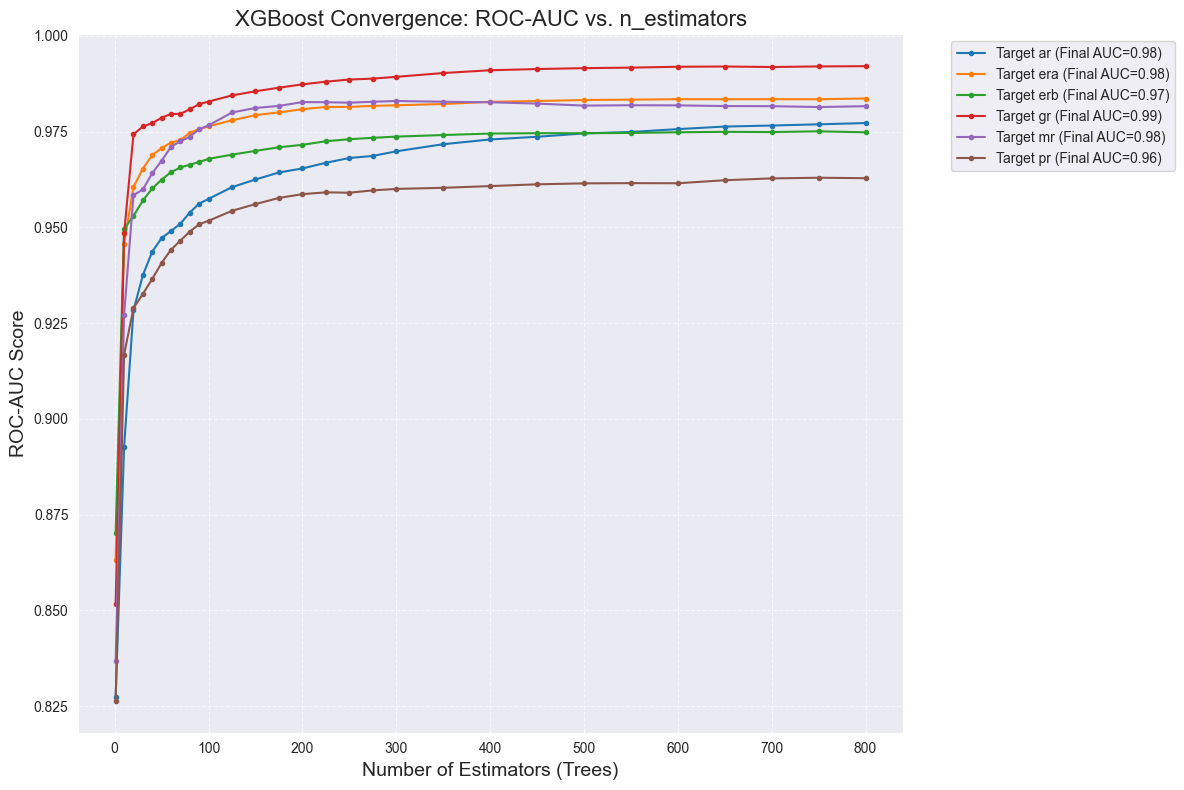

In [11]:
plt.figure(figsize=(12, 8))
cmap = matplotlib.colormaps.get_cmap('tab10')

for i in range(n_targets):
    color = cmap(i % 10)
    final_auc = history[i][-1]

    plt.plot(
        n_estimators_list,
        history[i],
        marker='.',
        linestyle='-',
        linewidth=1.5,
        label=f'Target {target_names[i]} (Final AUC={final_auc:.2f})',
        color=color
    )

plt.title("XGBoost Convergence: ROC-AUC vs. n_estimators", fontsize=16)
plt.xlabel("Number of Estimators (Trees)", fontsize=14)
plt.ylabel("ROC-AUC Score", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()